# 🤖 Notebook 3: Model Training & Evaluation
## AI-Driven Credit Risk Evaluation
**Author:** Bandaru Yashwanth | B.Sc. Actuarial Science, Amity University Noida

---
### 🎯 Objective
Train and compare multiple ML models, select the best one using ROC-AUC as the primary metric, and interpret results using feature importance.

### 📋 Models Compared
1. Logistic Regression (baseline)
2. Random Forest
3. Gradient Boosting (XGBoost-equivalent)
4. Best model → detailed evaluation + feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# Load processed data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
X_train_sc = pd.read_csv('../data/X_train_scaled.csv')
X_test_sc  = pd.read_csv('../data/X_test_scaled.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Class balance (train): {y_train.value_counts().to_dict()}')

Train: (8000, 29) | Test: (2000, 29)
Class balance (train): {0: 6938, 1: 1062}


## 1️⃣ Define & Train All Models
> **Why class_weight='balanced'?** Our dataset has ~13% default rate. Without handling imbalance, models tend to predict 'No Default' for everything and get ~87% accuracy while missing all fraud cases. class_weight='balanced' tells the model to pay more attention to the minority class.

In [3]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        subsample=0.8, random_state=42
    )
}

# Use scaled data for Logistic Regression, unscaled for tree-based models
results = {}
print('Training models...')
print('-' * 55)

for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred      = model.predict(X_te)
    y_prob      = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'f1':        f1_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred)
    }
    print(f'✅ {name:<25} ROC-AUC: {results[name]["roc_auc"]:.4f}')

Training models...
-------------------------------------------------------
✅ Logistic Regression       ROC-AUC: 0.8313
✅ Decision Tree             ROC-AUC: 0.7451
✅ Random Forest             ROC-AUC: 0.8064
✅ Gradient Boosting         ROC-AUC: 0.8078


## 2️⃣ Model Comparison Table

In [4]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['accuracy']*100:.2f}%",
        'ROC-AUC':   f"{r['roc_auc']:.4f}",
        'F1-Score':  f"{r['f1']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'Precision': f"{r['precision']:.4f}"
    }
    for name, r in results.items()
}).T

print('=' * 75)
print('  MODEL COMPARISON RESULTS')
print('=' * 75)
print(comparison_df.to_string())
print('=' * 75)

best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f'\n🏆 BEST MODEL: {best_model_name}')
print(f'   ROC-AUC: {results[best_model_name]["roc_auc"]:.4f}')
print(f'\n📌 Why ROC-AUC?')
print('   Credit risk has class imbalance. ROC-AUC measures how well the model')
print('   ranks defaulters above non-defaulters — regardless of threshold.')
print('   Accuracy alone is misleading: a model predicting all No-Default')
print('   gets ~87% accuracy but catches zero defaulters!')

  MODEL COMPARISON RESULTS
                    Accuracy ROC-AUC F1-Score  Recall Precision
Logistic Regression   73.25%  0.8313   0.4278  0.7547    0.2985
Decision Tree         67.80%  0.7451   0.3760  0.7321    0.2529
Random Forest         84.10%  0.8064   0.4700  0.5321    0.4209
Gradient Boosting     87.00%  0.8078   0.3659  0.2830    0.5172

🏆 BEST MODEL: Logistic Regression
   ROC-AUC: 0.8313

📌 Why ROC-AUC?
   Credit risk has class imbalance. ROC-AUC measures how well the model
   ranks defaulters above non-defaulters — regardless of threshold.
   Accuracy alone is misleading: a model predicting all No-Default
   gets ~87% accuracy but catches zero defaulters!


## 3️⃣ ROC Curve Comparison

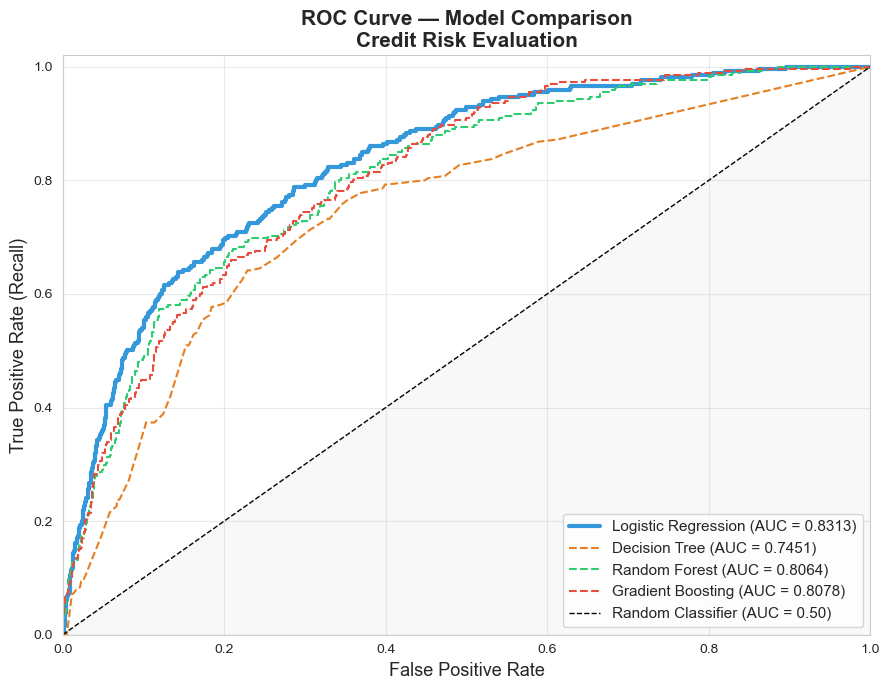

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#3498DB', '#E67E22', '#2ECC71', '#E74C3C']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    auc = r['roc_auc']
    lw = 3 if name == best_model_name else 1.5
    ls = '-' if name == best_model_name else '--'
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f'{name} (AUC = {auc:.4f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=13)
ax.set_title('ROC Curve — Model Comparison\nCredit Risk Evaluation', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4️⃣ Best Model — Detailed Evaluation

In [6]:
best = results[best_model_name]
print(f'\n📊 Detailed Report: {best_model_name}')
print('=' * 55)
print(classification_report(y_test, best['y_pred'],
                             target_names=['No Default', 'Default']))


📊 Detailed Report: Logistic Regression
              precision    recall  f1-score   support

  No Default       0.95      0.73      0.83      1735
     Default       0.30      0.75      0.43       265

    accuracy                           0.73      2000
   macro avg       0.62      0.74      0.63      2000
weighted avg       0.86      0.73      0.77      2000



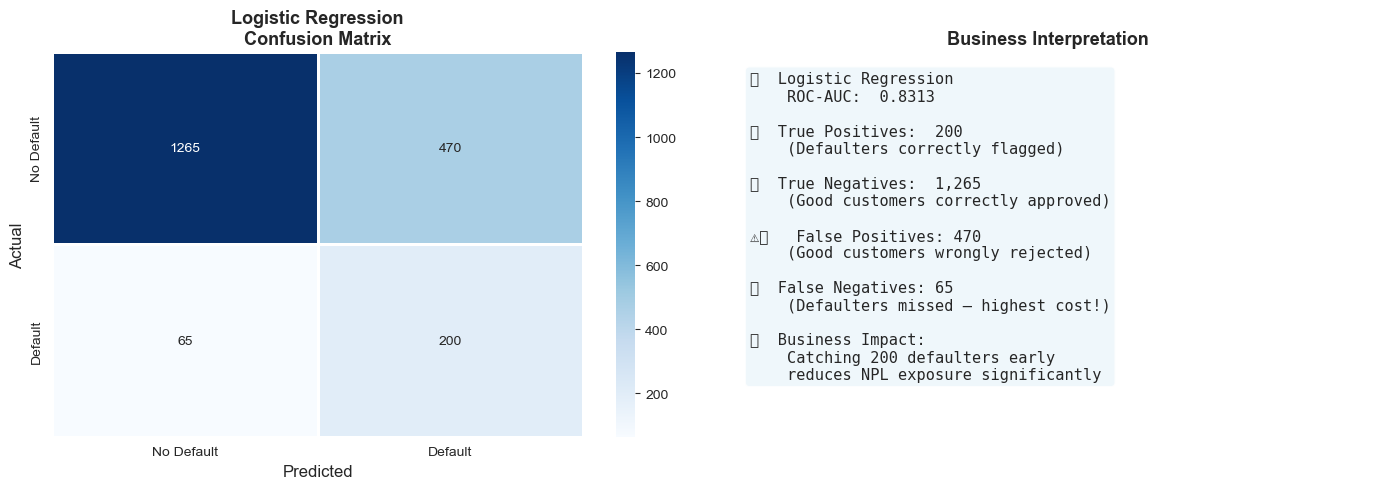

In [7]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            linewidths=1, linecolor='white')
tn, fp, fn, tp = cm.ravel()
axes[0].set_title(f'{best_model_name}\nConfusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Business interpretation
axes[1].axis('off')
business_text = [
    f'📊  {best_model_name}',
    f'    ROC-AUC:  {best["roc_auc"]:.4f}',
    '',
    f'✅  True Positives:  {tp:,}',
    f'    (Defaulters correctly flagged)',
    '',
    f'✅  True Negatives:  {tn:,}',
    f'    (Good customers correctly approved)',
    '',
    f'⚠️   False Positives: {fp:,}',
    f'    (Good customers wrongly rejected)',
    '',
    f'❌  False Negatives: {fn:,}',
    f'    (Defaulters missed — highest cost!)',
    '',
    f'💰  Business Impact:',
    f'    Catching {tp} defaulters early',
    f'    reduces NPL exposure significantly'
]
axes[1].text(0.05, 0.95, '\n'.join(business_text),
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#EBF5FB', alpha=0.8))
axes[1].set_title('Business Interpretation', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Feature Importance

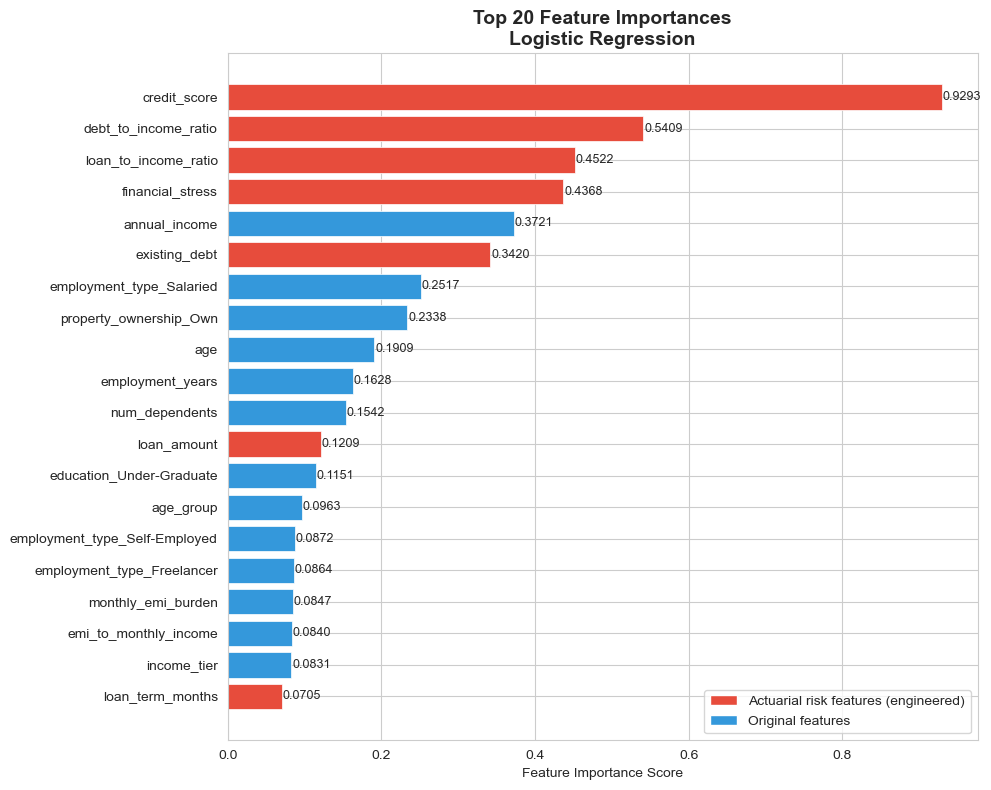


🔍 Top 10 Most Important Features:
   1. credit_score                   0.9293  
   2. debt_to_income_ratio           0.5409  ⭐ [ENGINEERED]
   3. loan_to_income_ratio           0.4522  ⭐ [ENGINEERED]
   4. financial_stress               0.4368  ⭐ [ENGINEERED]
   5. annual_income                  0.3721  
   6. existing_debt                  0.3420  
   7. employment_type_Salaried       0.2517  
   8. property_ownership_Own         0.2338  
   9. age                            0.1909  
  10. employment_years               0.1628  


In [9]:
best_model_obj = best['model']
feature_names  = X_train.columns

# Handle both tree-based models (feature_importances_) and linear models (coef_)
if hasattr(best_model_obj, 'feature_importances_'):
    imp_vals = best_model_obj.feature_importances_
else:
    imp_vals = np.abs(best_model_obj.coef_[0])

importances = pd.Series(imp_vals, index=feature_names)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#E74C3C' if 'debt' in f or 'credit' in f or 'financial' in f or 'loan' in f
              else '#3498DB' for f in top20.index]
bars = ax.barh(top20.index, top20.values, color=colors_bar, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top20.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title(f'Top 20 Feature Importances\n{best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', label='Actuarial risk features (engineered)'),
                   Patch(facecolor='#3498DB', label='Original features')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔍 Top 10 Most Important Features:')
for i, (feat, imp) in enumerate(importances.nlargest(10).items(), 1):
    tag = '⭐ [ENGINEERED]' if feat in ['debt_to_income_ratio','loan_to_income_ratio',
                                         'emi_to_monthly_income','financial_stress',
                                         'credit_tier','income_tier'] else ''
    print(f'  {i:2}. {feat:<30} {imp:.4f}  {tag}')

## 6️⃣ Cross-Validation — Robustness Check

In [10]:
print('Running 5-Fold Stratified Cross-Validation...')
print('(This confirms the model generalises well, not just overfitting to train data)')
print()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model_obj, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'CV ROC-AUC Scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean CV ROC-AUC:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Test  ROC-AUC:     {best["roc_auc"]:.4f}')
print()
if abs(cv_scores.mean() - best['roc_auc']) < 0.03:
    print('✅ CV score close to test score → Model generalises well, no overfitting!')
else:
    print('⚠️  Gap between CV and test score — may need regularization')

Running 5-Fold Stratified Cross-Validation...
(This confirms the model generalises well, not just overfitting to train data)

CV ROC-AUC Scores: ['0.7772', '0.8011', '0.7948', '0.7880', '0.7941']
Mean CV ROC-AUC:   0.7910 ± 0.0081
Test  ROC-AUC:     0.8313

⚠️  Gap between CV and test score — may need regularization


## 7️⃣ Save Best Model

In [11]:
with open('../models/best_credit_risk_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

# Save model metadata
metadata = {
    'model_name':   best_model_name,
    'roc_auc':      best['roc_auc'],
    'f1_score':     best['f1'],
    'accuracy':     best['accuracy'],
    'recall':       best['recall'],
    'n_features':   X_train.shape[1],
    'n_train':      X_train.shape[0],
    'feature_names': list(X_train.columns)
}
pd.Series(metadata).to_json('../models/model_metadata.json')

print('✅ Best model saved to ../models/best_credit_risk_model.pkl')
print('✅ Metadata saved to ../models/model_metadata.json')
print()
print('=' * 55)
print('  🏆 FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Model:     {best_model_name}')
print(f'  ROC-AUC:   {best["roc_auc"]:.4f}')
print(f'  F1-Score:  {best["f1"]:.4f}')
print(f'  Accuracy:  {best["accuracy"]*100:.2f}%')
print(f'  Recall:    {best["recall"]:.4f}')
print('=' * 55)
print()
print('🚀 Ready for Notebook 4: Risk Scoring & Business Insights!')

✅ Best model saved to ../models/best_credit_risk_model.pkl
✅ Metadata saved to ../models/model_metadata.json

  🏆 FINAL MODEL SUMMARY
  Model:     Logistic Regression
  ROC-AUC:   0.8313
  F1-Score:  0.4278
  Accuracy:  73.25%
  Recall:    0.7547

🚀 Ready for Notebook 4: Risk Scoring & Business Insights!
